In [23]:
from pathlib import Path
import shutil
import random
import csv
import json
import re
from collections import defaultdict

import numpy as np
import pandas as pd

import cv2 as cv
from skimage.io import imread

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


In [24]:
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

IMG_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"
}


def is_image_file(path):
    return path.is_file() and path.suffix.lower() in IMG_EXTS


def list_image_files(directory):
    directory = Path(directory)
    return sorted([p for p in directory.iterdir() if is_image_file(p)])


def safe_filename_part(name):
    """
    Zamienia nazwę klasy na bezpieczny fragment nazwy pliku.
    """
    return re.sub(r"[^a-zA-Z0-9_.-]+", "_", name)


In [25]:
def prepare_data_src(
    plantvillage_color_dir,
    data_src_dir="data_src",
    selected_classes=None,
    n_classes=10,
    min_images_per_class=250,
    max_files_per_class=800,
    copy_files=True
):

    plantvillage_color_dir = Path(plantvillage_color_dir)
    data_src_dir = Path(data_src_dir)

    if not plantvillage_color_dir.exists():
        raise FileNotFoundError(f"Nie znaleziono katalogu: {plantvillage_color_dir}")

    class_dirs = sorted([
        p for p in plantvillage_color_dir.iterdir()
        if p.is_dir()
    ])

    if selected_classes is None:
        candidates = []
        for cls_dir in class_dirs:
            files = list_image_files(cls_dir)
            if len(files) >= min_images_per_class:
                candidates.append(cls_dir)

        if len(candidates) < n_classes:
            raise ValueError(
                f"Found only {len(candidates)}"
            )

        chosen_dirs = candidates[:n_classes]

    else:
        chosen_dirs = []
        for cls_name in selected_classes:
            cls_dir = plantvillage_color_dir / cls_name
            if not cls_dir.exists():
                raise FileNotFoundError({cls_dir})

            files = list_image_files(cls_dir)
            if len(files) < min_images_per_class:
                raise ValueError(
                    "not enough images"
                )

            chosen_dirs.append(cls_dir)

    if data_src_dir.exists():
        shutil.rmtree(data_src_dir)

    data_src_dir.mkdir(parents=True, exist_ok=True)

    rng = random.Random(RANDOM_STATE)

    for cls_dir in chosen_dirs:
        files = list_image_files(cls_dir)
        rng.shuffle(files)

        if max_files_per_class is not None:
            files = files[:max_files_per_class]

        target_cls_dir = data_src_dir / cls_dir.name
        target_cls_dir.mkdir(parents=True, exist_ok=True)

        for src_file in files:
            dst_file = target_cls_dir / src_file.name

            if copy_files:
                shutil.copy2(src_file, dst_file)
            else:
                dst_file.symlink_to(src_file.resolve())

    print("data_src created:")
    for cls_dir in chosen_dirs:
        print(" -", cls_dir.name)

    return data_src_dir


Prepare data based on my path to the plantvillage dataset

In [26]:
PLANTVILLAGE_COLOR_DIR = Path("../plantvillage dataset/color")

SELECTED_CLASSES = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___healthy",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___healthy",
    "Grape___Black_rot",
    "Grape___healthy",
    "Potato___Early_blight",
    "Tomato___healthy",
]

data_src_path = prepare_data_src(
    plantvillage_color_dir=PLANTVILLAGE_COLOR_DIR,
    data_src_dir="../data_src",
    selected_classes=SELECTED_CLASSES,
    n_classes=10,
    min_images_per_class=250,
    max_files_per_class=800,
    copy_files=True
)


data_src created:
 - Apple___Apple_scab
 - Apple___Black_rot
 - Apple___healthy
 - Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 - Corn_(maize)___Common_rust_
 - Corn_(maize)___healthy
 - Grape___Black_rot
 - Grape___healthy
 - Potato___Early_blight
 - Tomato___healthy


In [27]:
def gen_train_test(container_dir, max_category_sample=500):
    """
    Generates a data directory containing:
        data/train/<class_name>/*.jpg
        data/test/*.jpg
        data/test_labels.csv
    """

    container_dir = Path(container_dir)

    if not container_dir.exists():
        raise FileNotFoundError(f"Directory not found: {container_dir}")

    data_dir = container_dir.parent / "data"
    train_dir = data_dir / "train"
    test_dir = data_dir / "test"

    if data_dir.exists():
        shutil.rmtree(data_dir)

    train_dir.mkdir(parents=True, exist_ok=True)
    test_dir.mkdir(parents=True, exist_ok=True)

    class_dirs = sorted(p for p in container_dir.iterdir() if p.is_dir())

    if not class_dirs:
        raise ValueError(f"Directory {container_dir} does not contain class subdirectories.")

    rng = random.Random(RANDOM_STATE)
    remaining_by_class = {}

    for class_dir in class_dirs:
        class_name = class_dir.name
        files = list_image_files(class_dir)

        if not files:
            print(f"Skipping empty class: {class_name}")
            continue

        rng.shuffle(files)

        train_files = files[:max_category_sample]
        remaining_files = files[max_category_sample:]

        target_train_class_dir = train_dir / class_name
        target_train_class_dir.mkdir(parents=True, exist_ok=True)

        for source_file in train_files:
            shutil.copy2(source_file, target_train_class_dir / source_file.name)

        remaining_by_class[class_name] = remaining_files

    if not remaining_by_class:
        raise ValueError("No data available to create the test set.")

    min_remaining = min(len(files) for files in remaining_by_class.values())

    if min_remaining == 0:
        raise ValueError(
            "At least one class has no images left after creating the train set. "
            "Decrease max_category_sample or increase the number of images per class."
        )

    label_rows = []

    for class_name, files in remaining_by_class.items():
        rng.shuffle(files)
        safe_class_name = safe_filename_part(class_name)

        for i, source_file in enumerate(files[:min_remaining]):
            target_name = f"{safe_class_name}__{i:05d}{source_file.suffix.lower()}"
            shutil.copy2(source_file, test_dir / target_name)

            label_rows.append({
                "filename": target_name,
                "label": class_name
            })

    labels_csv = data_dir / "test_labels.csv"

    with open(labels_csv, "w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=["filename", "label"])
        writer.writeheader()
        writer.writerows(label_rows)

    train_count = sum(1 for path in train_dir.rglob("*") if path.is_file())
    test_count = sum(1 for path in test_dir.rglob("*") if path.is_file())

    print(f"Created directory: {data_dir}")
    print(f"Train: {train_dir}")
    print(f"Test: {test_dir}")
    print(f"Test labels: {labels_csv}")
    print(f"Number of train images: {train_count}")
    print(f"Number of test images: {test_count}")

    return data_dir


Generate data dir

In [28]:
data_path = gen_train_test(
    container_dir="../data_src",
    max_category_sample=200
)

train_counts = {}

for cls_dir in sorted((data_path / "train").iterdir()):
    if cls_dir.is_dir():
        train_counts[cls_dir.name] = len(list_image_files(cls_dir))

train_counts_df = pd.DataFrame(
    train_counts.items(),
    columns=["class", "train_count"]
)

train_counts_df


Created directory: data
Train: data\train
Test: data\test
Test labels: data\test_labels.csv
Number of train images: 2000
Number of test images: 2230


,class,train_count
0,Apple___Apple_scab,200
1,Apple___Black_rot,200
2,Apple___healthy,200
3,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,200
4,Corn_(maize)___Common_rust_,200
5,Corn_(maize)___healthy,200
6,Grape___Black_rot,200
7,Grape___healthy,200
8,Potato___Early_blight,200
9,Tomato___healthy,200


In [29]:
test_labels_df = pd.read_csv(data_path / "test_labels.csv")

test_labels_df["label"].value_counts().to_frame("test_count")


,test_count
label,
Apple___Apple_scab,223
Apple___Black_rot,223
Apple___healthy,223
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,223
Corn_(maize)___Common_rust_,223
Corn_(maize)___healthy,223
Grape___Black_rot,223
Grape___healthy,223
Potato___Early_blight,223


## Komórka 7 — funkcje pomocnicze do wczytywania i przetwarzania obrazów

In [30]:
def process_image(
    image_path,
    newSize=(64, 64),
    interpol=cv.INTER_AREA,
    colorConv=None,
    ignore_image_a=True
):
    """
    Wczytuje obraz, usuwa kanał alfa, opcjonalnie konwertuje kolory,
    skaluje do newSize i spłaszcza.
    """

    img = imread(str(image_path))

    # Obraz czarno-biały zamieniamy na 3-kanałowy,
    # żeby zachować spójny rozmiar wektora cech.
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)

    # Usunięcie kanału alfa, jeśli istnieje.
    if ignore_image_a and img.ndim == 3 and img.shape[2] == 4:
        img = img[:, :, :3]

    # Konwersja kolorów OpenCV, np. cv.COLOR_RGB2GRAY.
    # Uwaga: skimage.io.imread wczytuje zwykle RGB, nie BGR.
    if colorConv is not None:
        img = cv.cvtColor(img, colorConv)

    img = cv.resize(img, newSize, interpolation=interpol)

    return img.reshape(-1)


def finalize_image_matrix(img_list, stand=False, norm=True):
    """
    Zamienia listę wektorów obrazów na np.array oraz stosuje:
        - standaryzację, jeśli stand=True,
        - normalizację do zakresu 0-1, jeśli norm=True.
    """

    X = np.asarray(img_list, dtype=np.float32)

    if stand:
        mean = X.mean(axis=0)
        std = X.std(axis=0)
        std[std == 0] = 1.0
        X = (X - mean) / std

    elif norm:
        max_value = X.max() if X.size else 1.0

        if max_value > 1.0:
            X = X / 255.0

    return X


def balanced_pairs_from_class_dirs(container_path, max_sample=None):
    """
    Zwraca pary:
        [(ścieżka_do_pliku, nazwa_klasy), ...]

    Dobór jest możliwie równomierny między klasami.
    """

    container_path = Path(container_path)

    class_dirs = sorted([
        p for p in container_path.iterdir()
        if p.is_dir()
    ])

    categories_name = [p.name for p in class_dirs]

    files_by_class = {}

    rng = random.Random(RANDOM_STATE)

    for cls_dir in class_dirs:
        files = list_image_files(cls_dir)
        rng.shuffle(files)
        files_by_class[cls_dir.name] = files

    total_available = sum(len(files) for files in files_by_class.values())

    if max_sample is None:
        max_sample = total_available

    max_sample = min(max_sample, total_available)

    result = []
    pointers = {cls_name: 0 for cls_name in files_by_class}

    # Round-robin po klasach, żeby zachować możliwie równą liczbę próbek.
    while len(result) < max_sample:
        added_any = False

        for cls_name in categories_name:
            files = files_by_class[cls_name]
            idx = pointers[cls_name]

            if idx < len(files):
                result.append((files[idx], cls_name))
                pointers[cls_name] += 1
                added_any = True

                if len(result) >= max_sample:
                    break

        if not added_any:
            break

    return result, categories_name


def balanced_pairs_from_test_dir(container_path, max_sample=None):
    """
    Zwraca pary:
        [(ścieżka_do_pliku, nazwa_klasy), ...]

    dla płaskiego katalogu data/test na podstawie pliku:
        data/test_labels.csv
    """

    container_path = Path(container_path)
    data_dir = container_path.parent

    csv_path = data_dir / "test_labels.csv"
    json_path = data_dir / "test_labels.json"

    labels = []

    if csv_path.exists():
        df = pd.read_csv(csv_path)

        for _, row in df.iterrows():
            labels.append({
                "filename": row["filename"],
                "label": row["label"]
            })

    elif json_path.exists():
        with open(json_path, "r", encoding="utf-8") as f:
            obj = json.load(f)

        if isinstance(obj, dict):
            for filename, label in obj.items():
                labels.append({
                    "filename": filename,
                    "label": label
                })

        elif isinstance(obj, list):
            labels = obj

        else:
            raise ValueError("Nieobsługiwany format test_labels.json")

    else:
        raise FileNotFoundError(
            f"Nie znaleziono {csv_path} ani {json_path}"
        )

    files_by_class = defaultdict(list)

    for item in labels:
        file_path = container_path / item["filename"]

        if file_path.exists():
            files_by_class[item["label"]].append(file_path)

    categories_name = sorted(files_by_class.keys())

    rng = random.Random(RANDOM_STATE)

    for cls_name in categories_name:
        rng.shuffle(files_by_class[cls_name])

    total_available = sum(len(files) for files in files_by_class.values())

    if max_sample is None:
        max_sample = total_available

    max_sample = min(max_sample, total_available)

    result = []
    pointers = {cls_name: 0 for cls_name in categories_name}

    # Round-robin po klasach.
    while len(result) < max_sample:
        added_any = False

        for cls_name in categories_name:
            files = files_by_class[cls_name]
            idx = pointers[cls_name]

            if idx < len(files):
                result.append((files[idx], cls_name))
                pointers[cls_name] += 1
                added_any = True

                if len(result) >= max_sample:
                    break

        if not added_any:
            break

    return result, categories_name


## Komórka 8 — funkcja `load_train_images`

In [31]:
def load_train_images(
    container_path,
    newSize=(64, 64),
    interpol=cv.INTER_AREA,
    colorConv=None,
    stand=False,
    ignore_image_a=True,
    norm=True,
    max_sample=200
):
    """
    Przygotowuje dane treningowe na podstawie katalogu data/train.

    Parametry:
        container_path:
            Ścieżka do katalogu data/train.

        newSize:
            Docelowy rozmiar obrazu dla cv.resize.

        interpol:
            Typ interpolacji OpenCV.

        colorConv:
            Stała konwersji OpenCV, np. cv.COLOR_RGB2GRAY.
            Jeśli None, brak konwersji.

        stand:
            Czy zastosować standaryzację.

        ignore_image_a:
            Czy usunąć kanał alfa.

        norm:
            Czy zastosować normalizację 0-1.

        max_sample:
            Maksymalna łączna liczba próbek.
            Dobór jest możliwie zrównoważony między klasami.

    Zwraca:
        Słownik:
            X["data"]
            X["categories_name"]
            X["categories_count"]
            X["labels"]
    """

    pairs, categories_name = balanced_pairs_from_class_dirs(
        container_path=container_path,
        max_sample=max_sample
    )

    train_img = []
    labels = []

    for file_path, label in pairs:
        try:
            flat_img = process_image(
                image_path=file_path,
                newSize=newSize,
                interpol=interpol,
                colorConv=colorConv,
                ignore_image_a=ignore_image_a
            )

            train_img.append(flat_img)
            labels.append(label)

        except Exception as e:
            print(f"Nie udało się wczytać {file_path}: {e}")

    X_data = finalize_image_matrix(
        train_img,
        stand=stand,
        norm=norm
    )

    X = {
        "data": X_data,
        "categories_name": categories_name,
        "categories_count": len(categories_name),
        "labels": labels
    }

    return X


## Komórka 9 — funkcja `load_test_images`

In [32]:
def load_test_images(
    container_path,
    newSize=(64, 64),
    interpol=cv.INTER_AREA,
    colorConv=None,
    stand=False,
    ignore_image_a=True,
    norm=True,
    max_sample=200
):
    """
    Przygotowuje dane testowe na podstawie katalogu data/test.

    Parametry:
        container_path:
            Ścieżka do katalogu data/test.

        newSize:
            Docelowy rozmiar obrazu dla cv.resize.

        interpol:
            Typ interpolacji OpenCV.

        colorConv:
            Stała konwersji OpenCV, np. cv.COLOR_RGB2GRAY.
            Jeśli None, brak konwersji.

        stand:
            Czy zastosować standaryzację.

        ignore_image_a:
            Czy usunąć kanał alfa.

        norm:
            Czy zastosować normalizację 0-1.

        max_sample:
            Maksymalna łączna liczba próbek testowych.
            Dobór jest możliwie zrównoważony między klasami.

    Zwraca:
        Słownik:
            X["data"]
            X["categories_name"]
            X["categories_count"]
            X["labels"]
    """

    pairs, categories_name = balanced_pairs_from_test_dir(
        container_path=container_path,
        max_sample=max_sample
    )

    test_img = []
    labels = []

    for file_path, label in pairs:
        try:
            flat_img = process_image(
                image_path=file_path,
                newSize=newSize,
                interpol=interpol,
                colorConv=colorConv,
                ignore_image_a=ignore_image_a
            )

            test_img.append(flat_img)
            labels.append(label)

        except Exception as e:
            print(f"Nie udało się wczytać {file_path}: {e}")

    X_data = finalize_image_matrix(
        test_img,
        stand=stand,
        norm=norm
    )

    X = {
        "data": X_data,
        "categories_name": categories_name,
        "categories_count": len(categories_name),
        "labels": labels
    }

    return X


## Komórka 10 — wczytanie danych treningowych i testowych

Wymaganie: obrazy `256x256`, minimum `200` przykładów na klasę i minimum `500` przykładów testowych.

Dla 10 klas:

- train: `10 * 200 = 2000`
- test: `500`

Jeżeli obliczenia są zbyt wolne lub występują problemy z RAM, można zmienić `IMG_SIZE` na `(128, 128)`.

In [33]:
IMG_SIZE = (256, 256)
# IMG_SIZE = (128, 128)

train_data = load_train_images(
    container_path=data_path / "train",
    newSize=IMG_SIZE,
    interpol=cv.INTER_AREA,
    colorConv=None,
    stand=False,
    ignore_image_a=True,
    norm=True,
    max_sample=2000
)

test_data = load_test_images(
    container_path=data_path / "test",
    newSize=IMG_SIZE,
    interpol=cv.INTER_AREA,
    colorConv=None,
    stand=False,
    ignore_image_a=True,
    norm=True,
    max_sample=500
)

X_train = train_data["data"]
X_test = test_data["data"]

y_train_labels = train_data["labels"]
y_test_labels = test_data["labels"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Liczba klas train:", train_data["categories_count"])
print("Liczba klas test:", test_data["categories_count"])


X_train: (2000, 196608)
X_test: (500, 196608)
Liczba klas train: 10
Liczba klas test: 10


kodowanie etykiet

In [34]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train_labels)
y_test = label_encoder.transform(y_test_labels)

print("Klasy:")
for idx, cls_name in enumerate(label_encoder.classes_):
    print(idx, cls_name)


Klasy:
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___healthy
3 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
4 Corn_(maize)___Common_rust_
5 Corn_(maize)___healthy
6 Grape___Black_rot
7 Grape___healthy
8 Potato___Early_blight
9 Tomato___healthy


evalueate helper

In [35]:
def evaluate_model(model, X_test, y_test, label_encoder, title="Model"):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=np.arange(len(label_encoder.classes_))
    )

    acc = accuracy_score(y_test, y_pred)

    precision_macro = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision_weighted = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    metrics_dict = {
        "model": title,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }

    print(title)
    print()
    print("Accuracy:", acc)
    print("Precision macro:", precision_macro)
    print("Recall macro:", recall_macro)
    print("F1 macro:", f1_macro)
    print()
    print("Classification report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

    fig, ax = plt.subplots(figsize=(12, 10))
    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format="d"
    )
    plt.title(f"Macierz pomyłek — {title}")
    plt.show()

    return metrics_dict, cm, y_pred


## model 1: Logistic Regression OVR

In [36]:
base_model_ovr = LogisticRegression(
    solver="saga",
    max_iter=200,
    tol=1e-2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

model_ovr = OneVsRestClassifier(
    estimator=base_model_ovr,
    n_jobs=-1
)

model_ovr.fit(X_train, y_train)


,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.","LogisticRegre...01, verbose=1)"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.01
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=No

LogisticRegression OVR

Accuracy: 0.882
Precision macro: 0.8836192390673604
Recall macro: 0.882
F1 macro: 0.8819907177183298

Classification report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.84      0.82      0.83        50
                                 Apple___Black_rot       0.87      0.82      0.85        50
                                   Apple___healthy       0.83      0.78      0.80        50
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.90      0.94        50
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99        50
                            Corn_(maize)___healthy       0.94      1.00      0.97        50
                                 Grape___Black_rot       0.88      0.86      0.87        50
                                   Grape___healthy       0.75      0.86      0.80        50
                      

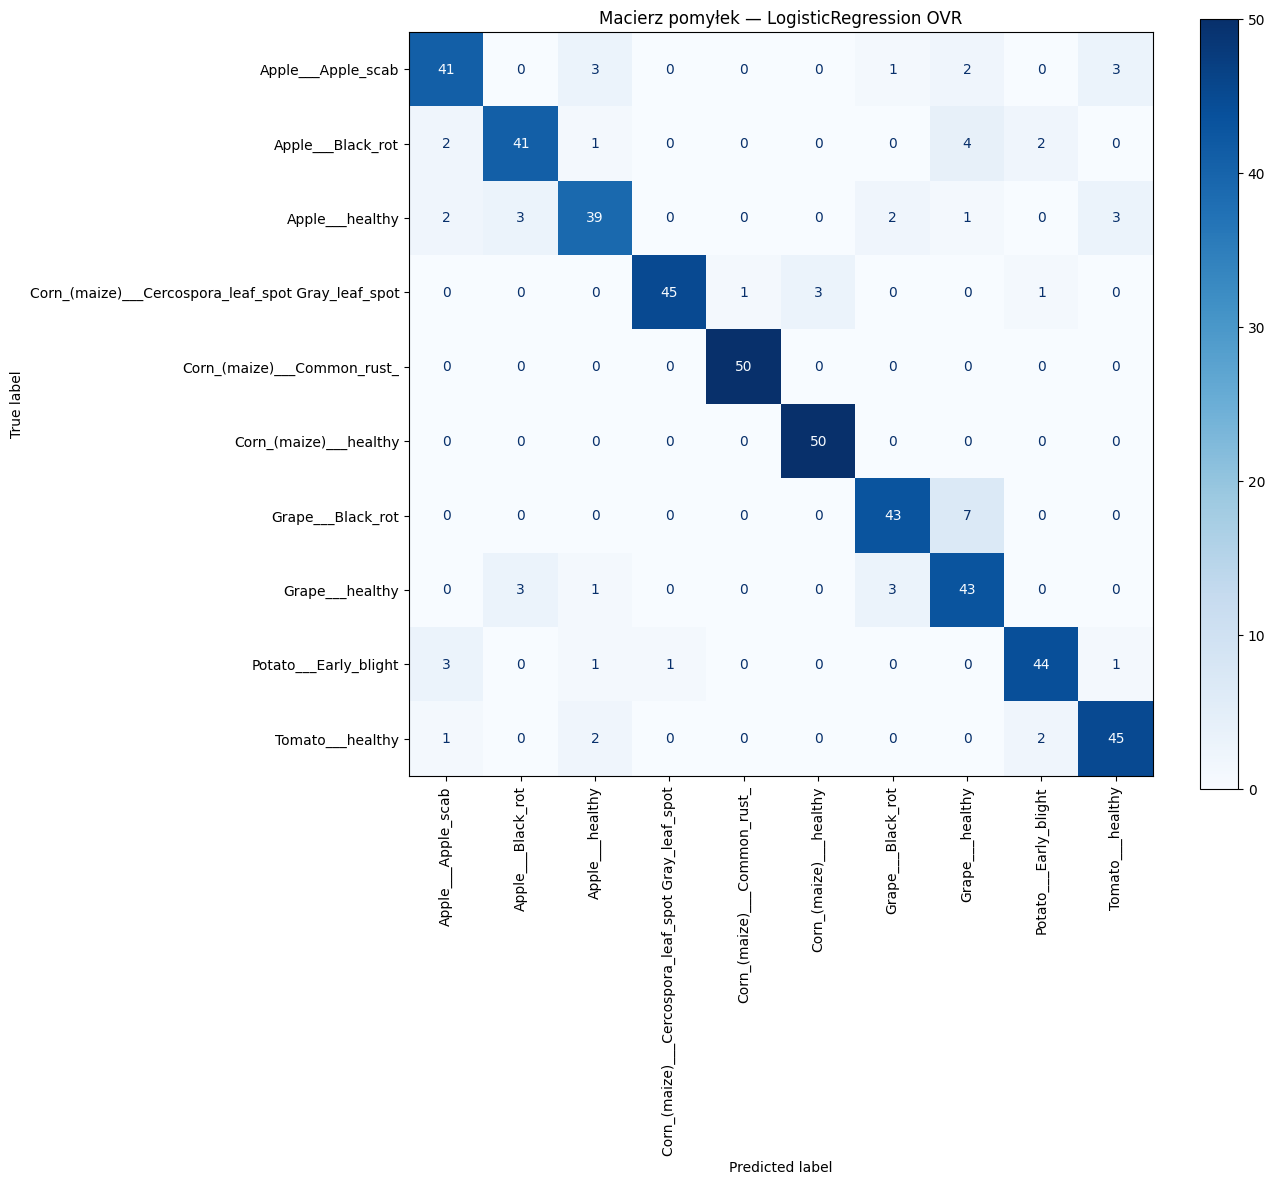

In [37]:
metrics_ovr, cm_ovr, y_pred_ovr = evaluate_model(
    model=model_ovr,
    X_test=X_test,
    y_test=y_test,
    label_encoder=label_encoder,
    title="LogisticRegression OVR"
)


## model 2: Logistic Regression multinomial

In [38]:
model_multinomial = LogisticRegression(
    solver="saga",
    max_iter=200,
    tol=1e-2,
    random_state=RANDOM_STATE,
    verbose=1
)

model_multinomial.fit(X_train, y_train)


convergence after 44 epochs took 596 seconds


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.01
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

LogisticRegression Multinomial

Accuracy: 0.872
Precision macro: 0.8743167305569571
Recall macro: 0.8719999999999999
F1 macro: 0.8725217032040575

Classification report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.75      0.84      0.79        50
                                 Apple___Black_rot       0.84      0.84      0.84        50
                                   Apple___healthy       0.81      0.78      0.80        50
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.88      0.89        50
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99        50
                            Corn_(maize)___healthy       0.98      0.96      0.97        50
                                 Grape___Black_rot       0.88      0.86      0.87        50
                                   Grape___healthy       0.80      0.86      0.83        50
 

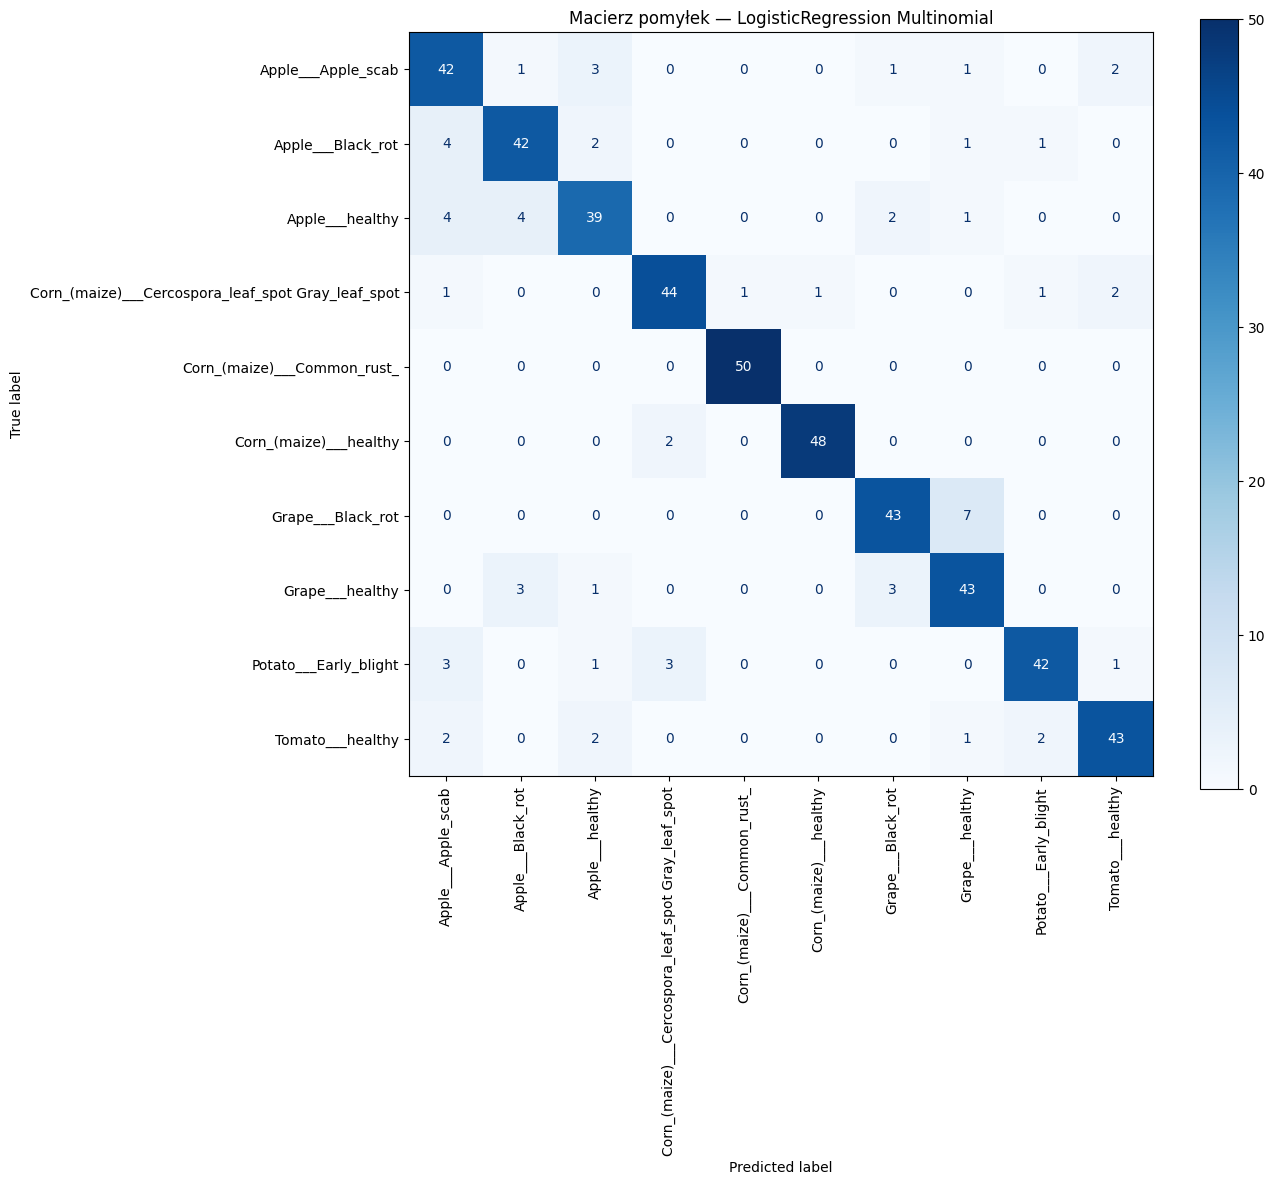

In [39]:
metrics_multinomial, cm_multinomial, y_pred_multinomial = evaluate_model(
    model=model_multinomial,
    X_test=X_test,
    y_test=y_test,
    label_encoder=label_encoder,
    title="LogisticRegression Multinomial"
)


## porównanie wyników

In [40]:
results_df = pd.DataFrame([
    metrics_ovr,
    metrics_multinomial
])

results_df


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,LogisticRegression OVR,0.882,0.883619,0.882,0.881991,0.883619,0.882,0.881991
1,LogisticRegression Multinomial,0.872,0.874317,0.872,0.872522,0.874317,0.872,0.872522
